# TabNet

## Что такое TabNet?

**TabNet** (Arik & Pfister, Google, 2019) - первая нейросетевая архитектура, разработанная специально для **табличных данных**. В отличие от полносвязных сетей, где все признаки используются одновременно, TabNet на каждом шаге выбирает **подмножество признаков** через механизм внимания - как дерево решений, но дифференцируемо.

### Ключевые компоненты

#### 1. Sequential Attention (последовательное внимание)
Модель делает **N_steps шагов**. На каждом шаге:
- Выбирается подмножество признаков (через Attentive Transformer)
- Выбранные признаки обрабатываются (через Feature Transformer)
- Результат аккумулируется в итоговый выход

Аналогия с деревьями: каждый шаг ≈ один уровень дерева, но вместо жёсткого «если x > 5» - мягкая дифференцируемая маска.

#### 2. Feature Transformer
Два слоя GLU (Gated Linear Unit) на каждом шаге:
- **Shared** (общий) - параметры разделяются между всеми шагами, отвечает за общие паттерны
- **Step-specific** (индивидуальный) - свои параметры на каждом шаге, отвечает за специализацию

GLU: `FC(x) ⊗ sigmoid(FC(x))` - gate контролирует, какая информация проходит дальше.

#### 3. Attentive Transformer + Sparsemax
На каждом шаге вычисляется маска внимания:
```
M[i] = sparsemax(P[i-1] ⊗ h_att[i])
```
- `sparsemax` - аналог softmax, но с настоящими нулями (не просто маленькими числами)
- Модель выбирает **небольшое число признаков** на каждом шаге и полностью игнорирует остальные
- Именно это делает TabNet **интерпретируемым** - можно посмотреть, какие признаки важны на каждом шаге

#### 4. Prior Scale Factor γ (гамма)
```
P[i] = P[i-1] ⊗ (γ - M[i-1])
```
Штраф за повторное использование признака на разных шагах:
- `γ = 1.0`: признак, использованный на шаге 1, получит нулевой вес на шаге 2 - максимальное разнообразие
- `γ → ∞`: штрафа нет, признаки могут повторяться - поведение ближе к обычной сети
- Типичные значения: 1.2–2.0

#### 5. Sparse Regularization λ_sparse
Дополнительный штраф в функции потерь, поощряющий разреженность масок:
```
L = L_task + λ_sparse * Σ_i H(M[i])
```
где `H` - энтропия маски. Чем больше λ_sparse, тем меньше признаков использует модель.

### Схема архитектуры
*(рисунки из оригинальной статьи - Arik & Pfister, 2019, arXiv:1908.07442)*

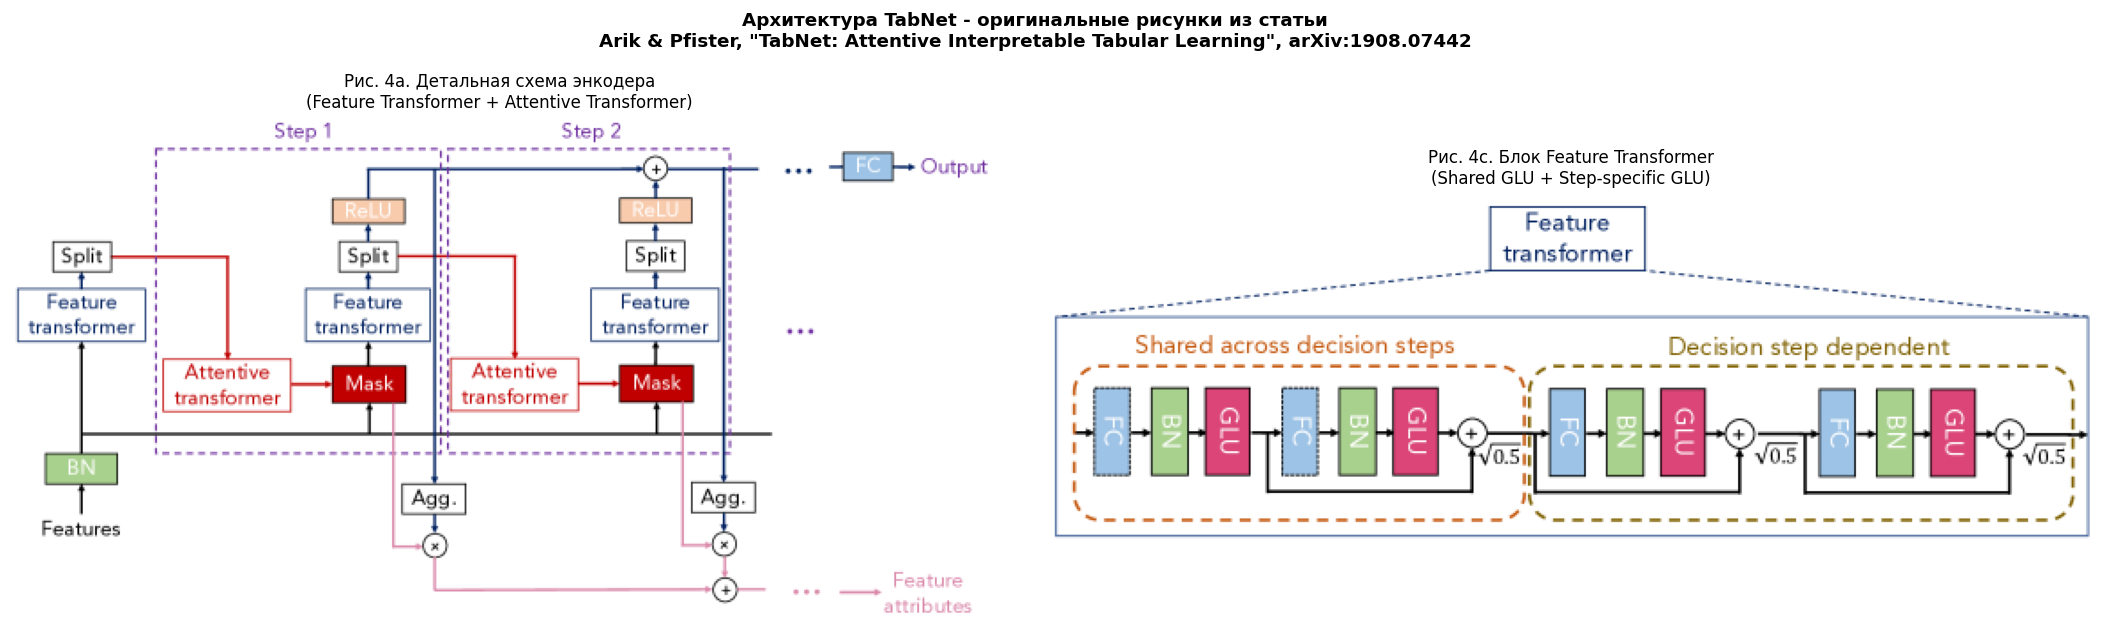

In [48]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor('white')

imgs   = ['images/tabnet_arch_encoder.png', 'images/tabnet_arch_ft.png']
titles = [
    'Рис. 4a. Детальная схема энкодера\n(Feature Transformer + Attentive Transformer)',
    'Рис. 4c. Блок Feature Transformer\n(Shared GLU + Step-specific GLU)',
]

for ax, img_path, title in zip(axes, imgs, titles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10, pad=8)

plt.suptitle(
    'Архитектура TabNet - оригинальные рисунки из статьи\n'
    'Arik & Pfister, "TabNet: Attentive Interpretable Tabular Learning", arXiv:1908.07442',
    fontsize=11, fontweight='bold', y=1.04,
)
plt.tight_layout()
plt.show()

## 1. Импорты и конфигурация

In [ ]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import optuna

from pytorch_tabnet.tab_model import TabNetRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RANDOM_STATE = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_PATH = Path('../../data/train_data_v2.csv')
MODELS_DIR = Path('../../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'Device  : {DEVICE}', f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

Device  : cuda (NVIDIA GeForce RTX 5080)


## 2. Загрузка данных и группировка признаков

In [50]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк × {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}  std={df["target"].std():.4f}')

Датасет: 6200 строк × 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008  std=0.0859


In [51]:
# Группы признаков
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
CONT_COLS = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]

print(f'Всего признаков : {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Всего признаков : 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Препроцессинг

**Особенности препроцессинга для TabNet:**
- TabNet принимает `numpy float32` массив, где категориальные признаки - **целочисленные индексы** (не one-hot)
- Категориальные колонки передаются последними, их индексы указываются через `cat_idxs`
- `cat_dims` - количество уникальных значений +1 (зарезервировано под unknown при инференсе)

**Разбивка train / val / test = 70% / 15% / 15%**
- Early stopping и Optuna оптимизируют по **val** - модель не видит test до финального отчёта
- Финальные метрики считаются **один раз на test**

In [52]:
X = df[ALL_FEATURES].copy()
y = df['target'].values.reshape(-1, 1).astype(np.float32)

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

strat_col = df['city_size_category'].fillna('unknown')

# Отделяем test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
# Из оставшихся отделяем val (~15% от всего)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Непрерывные: imputer → log1p для расстояний → scaler
imp_cont = SimpleImputer(strategy='median')
scaler = StandardScaler()

def process_cont(X_df, fit=False):
    vals = X_df[CONT_COLS].copy().astype(float)
    for c in DISTANCE_FEATURES:
        if c in vals.columns:
            vals[c] = np.log1p(vals[c].clip(lower=0))
    if fit:
        imp_cont.fit(vals)
        scaler.fit(imp_cont.transform(vals))
    return scaler.transform(imp_cont.transform(vals)).astype(np.float32)

# Категориальные: fillna('unknown') → OrdinalEncoder
enc_cat = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1,
    dtype=np.float32,
)

def process_cat(X_df, fit=False):
    vals = X_df[CATEGORICAL_FEATURES].fillna('unknown').astype(str)
    if fit:
        enc_cat.fit(vals)
    encoded = enc_cat.transform(vals).astype(np.float32)
    for j in range(encoded.shape[1]):
        n_known = len(enc_cat.categories_[j])
        encoded[:, j] = np.where(encoded[:, j] < 0, float(n_known), encoded[:, j])
    return encoded

# Fit только на train
process_cont(X_train, fit=True)
process_cat(X_train, fit=True)

X_train_np = np.hstack([process_cont(X_train), process_cat(X_train)])
X_val_np = np.hstack([process_cont(X_val), process_cat(X_val)])
X_test_np = np.hstack([process_cont(X_test), process_cat(X_test)])
X_trainval_np = np.vstack([X_train_np, X_val_np])
y_trainval_np = np.vstack([y_train, y_val])

cat_idxs = list(range(len(CONT_COLS), len(CONT_COLS) + len(CATEGORICAL_FEATURES)))
cat_dims = [len(enc_cat.categories_[j]) + 1 for j in range(len(CATEGORICAL_FEATURES))]

print(f'Train : {X_train_np.shape}  |  Val : {X_val_np.shape}  |  Test : {X_test_np.shape}')

Train : (4339, 67)  |  Val : (931, 67)  |  Test : (930, 67)


## 4. Вспомогательные функции

In [ ]:
def timed_fit(model, X, y, eval_set, patience=50, max_epochs=500, batch_size=1024):
    t0 = time.perf_counter()
    model.fit(
        X, y,
        eval_set=eval_set,
        patience=patience,
        max_epochs=max_epochs,
        batch_size=batch_size,
        eval_metric=['rmse'],
    )
    return model, time.perf_counter() - t0


def timed_predict(model, X):
    t0 = time.perf_counter()
    preds = model.predict(X).flatten()
    return preds, time.perf_counter() - t0


def report_metrics(model_name, model, X_train, y_train, X_test, y_test, fit_time):
    y_tr = y_train.flatten()
    y_te = y_test.flatten()

    y_pred_train, train_pred_time = timed_predict(model, X_train)
    y_pred_test,  test_pred_time  = timed_predict(model, X_test)

    def _m(yt, yp):
        return {
            'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
            'MAE' : round(float(mean_absolute_error(yt, yp)), 4),
            'R²'  : round(float(r2_score(yt, yp)), 4),
        }

    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)

    table = pd.DataFrame([
        {'Split': 'Train',
         'RMSE': train_m['RMSE'], 'MAE': train_m['MAE'], 'R²': train_m['R²'],
         'Fit time, s': round(fit_time, 2), 'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',
         'RMSE': test_m['RMSE'], 'MAE': test_m['MAE'], 'R²': test_m['R²'],
         'Fit time, s': float('nan'), 'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')

    print(f'\n{model_name}')
    display(
        table.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                 'Fit time, s': lambda v: f'{v:.2f}' if not np.isnan(v) else '-',
                 'Predict time, s': '{:.4f}'})
        .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
        .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²'])
    )

    return {
        'Model': model_name,
        'RMSE': test_m['RMSE'], 'MAE': test_m['MAE'], 'R²': test_m['R²'],
        'Fit time, s': round(fit_time, 2),
    }, y_pred_test


def plot_loss(model, title):
    history = model.history
    train_loss = history['loss']
    val_loss = history['val_0_rmse']
    epochs = range(1, len(train_loss) + 1)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, train_loss, color='#3498db', label='Train loss', linewidth=1.8)
    ax.plot(epochs, val_loss,   color='#e74c3c', label='Val RMSE',   linewidth=1.8)
    best_epoch = int(np.argmin(val_loss)) + 1
    ax.axvline(best_epoch, color='#e67e22', linestyle='--', alpha=0.8,
               label=f'Best epoch={best_epoch} (RMSE={min(val_loss):.4f})')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Loss / RMSE')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_attention(model, X, feat_names, title, top_n=20):
    explain_matrix, masks = model.explain(X)
    mean_importance = explain_matrix.mean(axis=0)
    imp_series = pd.Series(mean_importance, index=feat_names).sort_values(ascending=False)

    # Барчарт top-N признаков
    top = imp_series.head(top_n)
    fig1, ax1 = plt.subplots(figsize=(9, 7))
    ax1.barh(top.index[::-1], top.values[::-1], color='#3498db', edgecolor='white')
    ax1.set_xlabel('Среднее внимание (explain_matrix)')
    ax1.set_title(f'{title} - Top-{top_n} признаков по вниманию')
    ax1.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Тепловая карта масок по шагам
    top15_names  = imp_series.head(15).index.tolist()
    top15_idx = [feat_names.index(n) for n in top15_names]
    n_steps = len(masks)
    heatmap_data = np.array([m.mean(axis=0)[top15_idx] for m in masks.values()])

    fig2, ax2 = plt.subplots(figsize=(14, max(3, n_steps * 1.1)))
    sns.heatmap(
        heatmap_data,
        xticklabels=top15_names,
        yticklabels=[f'Step {i+1}' for i in range(n_steps)],
        cmap='Blues', annot=True, fmt='.2f', linewidths=0.5,
        annot_kws={'size': 9},
        ax=ax2,
    )
    ax2.set_title(f'{title} - маски внимания по шагам (top-15)')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    return explain_matrix, masks

## 5. Эксперимент 1 - Базовый TabNet

Стартовые гиперпараметры из оригинальной статьи TabNet:  
- `n_d = n_a = 32` - размерность эмбеддинга шага и внимания  
- `n_steps = 5` - количество шагов последовательного внимания  
- `gamma = 1.3` - умеренный штраф за повтор признаков  
- `lambda_sparse = 1e-3` - слабая разреженность масок

In [37]:
model_base = TabNetRegressor(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-3,
    n_independent=2,
    n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=30, gamma=0.9),
    mask_type='sparsemax',
    device_name=DEVICE,
    seed=RANDOM_STATE,
    verbose=10,
)

model_base, fit_time_base = timed_fit(
    model_base, X_train_np, y_train,
    eval_set=[(X_val_np, y_val)],
    patience=50,
    max_epochs=500,
)

epoch 0  | loss: 4.88069 | val_0_rmse: 0.9508  |  0:00:00s
epoch 10 | loss: 0.0539  | val_0_rmse: 0.2644  |  0:00:02s
epoch 20 | loss: 0.01059 | val_0_rmse: 0.09255 |  0:00:04s
epoch 30 | loss: 0.00739 | val_0_rmse: 0.08229 |  0:00:06s
epoch 40 | loss: 0.00659 | val_0_rmse: 0.07904 |  0:00:08s
epoch 50 | loss: 0.00626 | val_0_rmse: 0.07513 |  0:00:10s
epoch 60 | loss: 0.00601 | val_0_rmse: 0.07655 |  0:00:12s
epoch 70 | loss: 0.00594 | val_0_rmse: 0.07948 |  0:00:14s
epoch 80 | loss: 0.00606 | val_0_rmse: 0.07734 |  0:00:16s
epoch 90 | loss: 0.00567 | val_0_rmse: 0.07236 |  0:00:18s
epoch 100| loss: 0.0055  | val_0_rmse: 0.07105 |  0:00:20s
epoch 110| loss: 0.00545 | val_0_rmse: 0.07189 |  0:00:22s
epoch 120| loss: 0.00538 | val_0_rmse: 0.07364 |  0:00:24s
epoch 130| loss: 0.00529 | val_0_rmse: 0.07179 |  0:00:26s
epoch 140| loss: 0.00505 | val_0_rmse: 0.07147 |  0:00:28s
epoch 150| loss: 0.00503 | val_0_rmse: 0.07093 |  0:00:30s
epoch 160| loss: 0.00496 | val_0_rmse: 0.07002 |  0:00:3


TabNet - Базовый


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0472,0.0375,0.7004,77.63,0.0903
Test,0.0500,0.0403,0.6647,-,0.0188


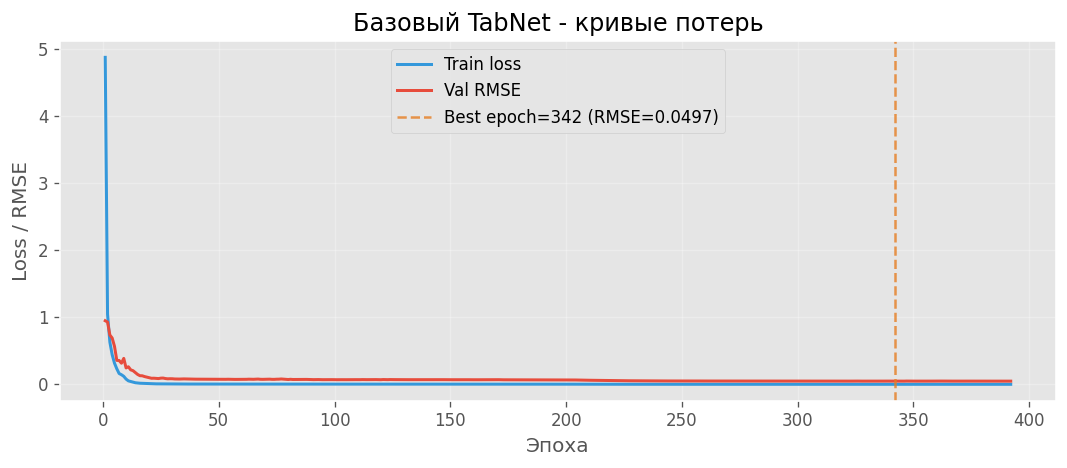

In [38]:
row_base, pred_base = report_metrics(
    'TabNet - Базовый',
    model_base, X_train_np, y_train, X_test_np, y_test, fit_time_base,
)
plot_loss(model_base, 'Базовый TabNet - кривые потерь')

## 6. Визуализация масок внимания

**Уникальная возможность TabNet** - интерпретируемость «из коробки» без SHAP/LIME.  
`model.explain(X)` возвращает:
- `explain_matrix`: суммарная важность каждого признака по всем шагам (усреднённая по объектам)
- `masks`: список из N_steps матриц - отдельная маска внимания для каждого шага

Тепловая карта показывает **на каком шаге модель фокусируется на каком признаке** - это позволяет понять логику решений.

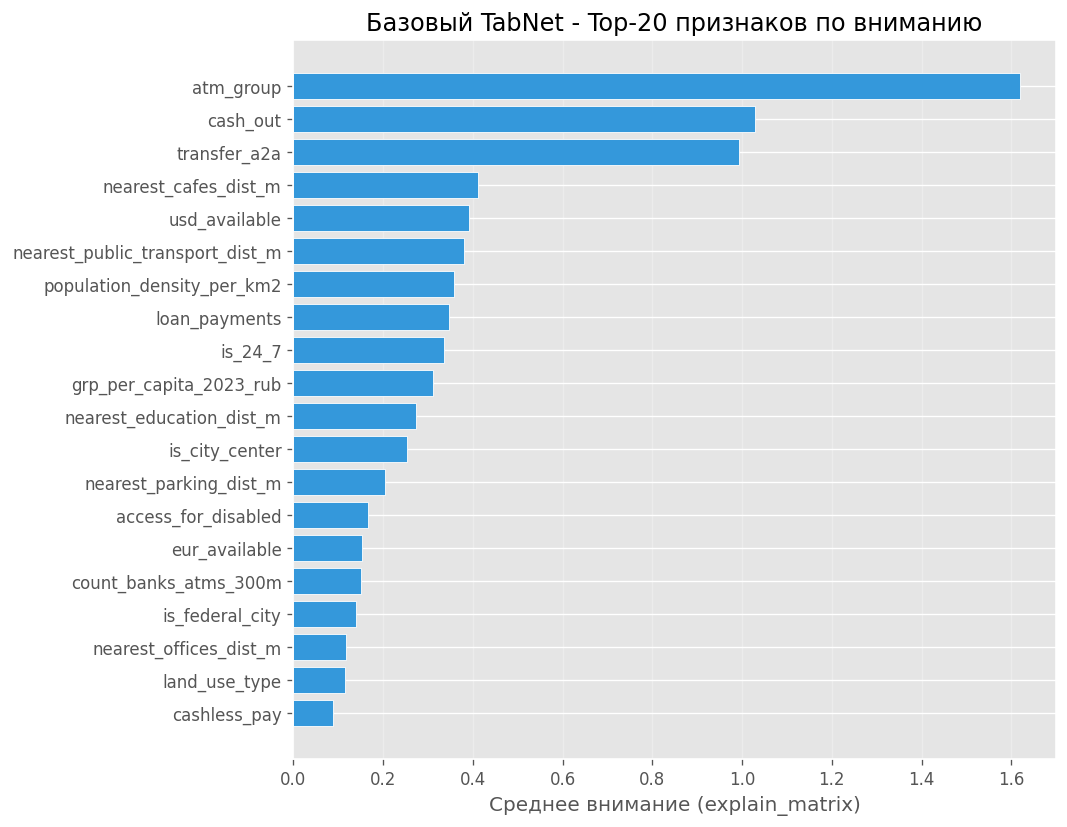

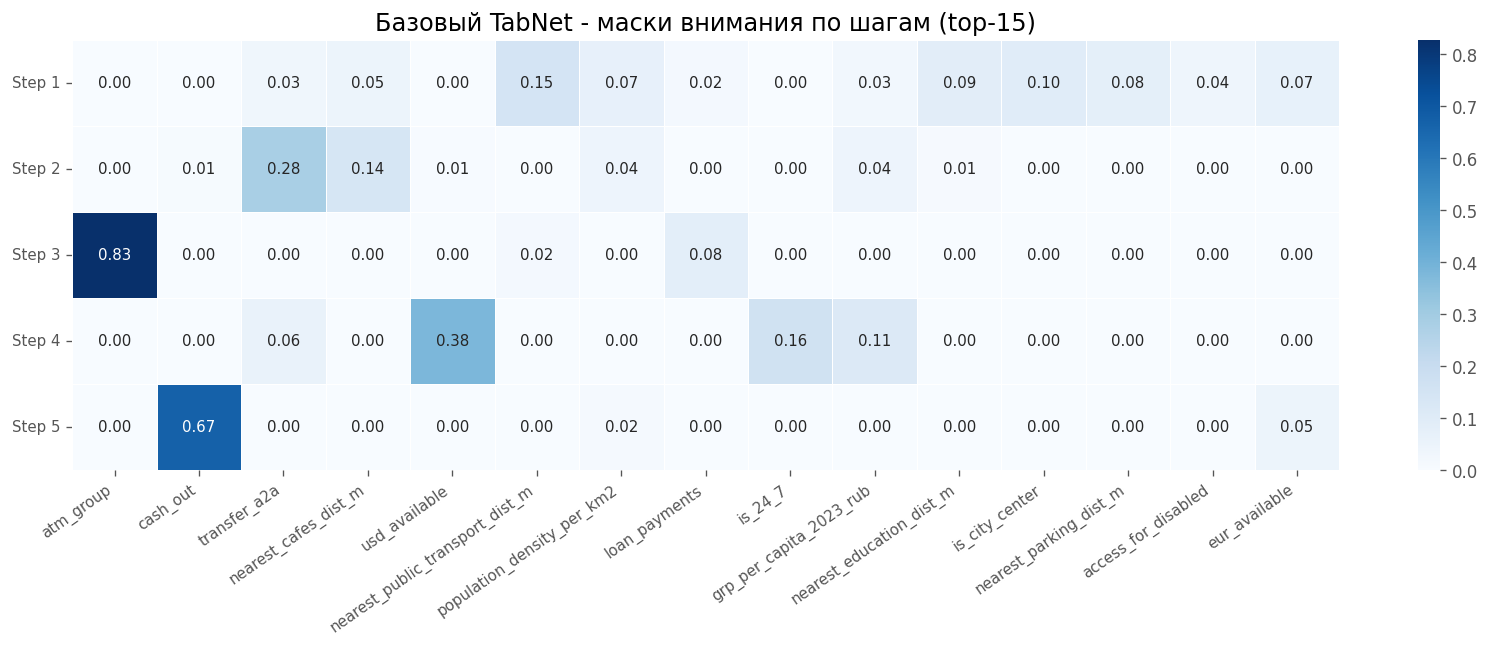

In [39]:
feat_names = CONT_COLS + CATEGORICAL_FEATURES

explain_base, masks_base = plot_attention(
    model_base, X_test_np, feat_names,
    title='Базовый TabNet',
)

## 7. Эксперимент 2 - Подбор гиперпараметров (Optuna)

Пространство поиска охватывает ключевые гиперпараметры TabNet:  
- `n_d / n_a` - ширина сети (8–64)  
- `n_steps` - глубина (3–8)  
- `gamma` - спарсити через prior scale (1.0–2.0)  
- `lambda_sparse` - прямая регуляризация масок (1e-4 – 1e-2)  
- `lr` - скорость обучения  
- `momentum` - momentum для BatchNorm

In [ ]:
def objective(trial):
    n_d = trial.suggest_int('n_d', 8, 64, step=8)
    n_steps = trial.suggest_int('n_steps', 3, 8)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-4, 1e-2, log=True)
    lr = trial.suggest_float('lr', 5e-3, 5e-2, log=True)
    momentum = trial.suggest_float('momentum', 0.01, 0.4)

    model = TabNetRegressor(
        n_d=n_d, n_a=n_d,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        n_independent=2,
        n_shared=2,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=lr),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=30, gamma=0.9),
        momentum=momentum,
        mask_type='sparsemax',
        device_name=DEVICE,
        seed=RANDOM_STATE,
        verbose=0,
    )

    model.fit(
        X_train_np, y_train,
        eval_set=[(X_val_np, y_val)],
        patience=50,
        max_epochs=500,
        batch_size=1024,
        eval_metric=['rmse'],
    )

    preds = model.predict(X_val_np).flatten()
    return float(np.sqrt(mean_squared_error(y_val.flatten(), preds)))


study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='tabnet_tuning',
)
print('Запускаем Optuna (30 trials)...')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nЛучший RMSE (val) : {study.best_value:.4f}')
print(f'Лучшие params: {study.best_params}')

Запускаем Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 207 with best_epoch = 157 and best_val_0_rmse = 0.07614

Early stopping occurred at epoch 337 with best_epoch = 287 and best_val_0_rmse = 0.07367
Stop training because you reached max_epochs = 500 with best_epoch = 498 and best_val_0_rmse = 0.06338
Stop training because you reached max_epochs = 500 with best_epoch = 490 and best_val_0_rmse = 0.05326

Early stopping occurred at epoch 170 with best_epoch = 120 and best_val_0_rmse = 0.07384

Early stopping occurred at epoch 284 with best_epoch = 234 and best_val_0_rmse = 0.05064

Early stopping occurred at epoch 313 with best_epoch = 263 and best_val_0_rmse = 0.07155

Early stopping occurred at epoch 182 with best_epoch = 132 and best_val_0_rmse = 0.07326

Early stopping occurred at epoch 305 with best_epoch = 255 and best_val_0_rmse = 0.05162

Early stopping occurred at epoch 264 with best_epoch = 214 and best_val_0_rmse = 0.051

Early stopping occurred at epoch 177 with best_epoch = 127 and best_val_0_r

Top-5 trials:


,Trial,RMSE (val),params_n_d,params_n_steps,params_gamma,params_lambda_sparse,params_lr,params_momentum
0,27,0.0492,16,7,1.436,0.00030,0.01744,0.013
1,24,0.0492,16,7,1.515,0.00016,0.01184,0.081
2,28,0.0494,16,6,1.330,0.00064,0.00904,0.073
3,15,0.0496,48,3,1.342,0.00048,0.01929,0.260
4,26,0.0497,16,7,1.451,0.00030,0.01658,0.031


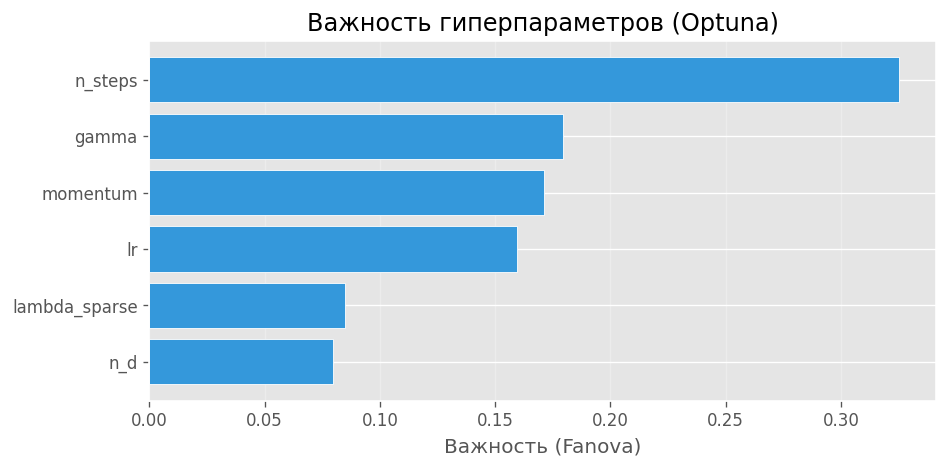

In [41]:
# Таблица top-5 trials
trials_df = study.trials_dataframe()
top5 = (
    trials_df[trials_df['state'] == 'COMPLETE']
    .sort_values('value')
    .head(5)[['number', 'value', 'params_n_d', 'params_n_steps',
               'params_gamma', 'params_lambda_sparse', 'params_lr', 'params_momentum']]
    .rename(columns={'number': 'Trial', 'value': 'RMSE (val)'})
    .reset_index(drop=True)
)
print('Top-5 trials:')
display(top5.style.format({'RMSE (val)': '{:.4f}', 'params_gamma': '{:.3f}',
                            'params_lambda_sparse': '{:.5f}', 'params_lr': '{:.5f}',
                            'params_momentum': '{:.3f}'}))

# График важности гиперпараметров
importances = optuna.importance.get_param_importances(study)
imp_series = pd.Series(importances).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_series.index, imp_series.values, color='#3498db', edgecolor='white')
ax.set_xlabel('Важность (Fanova)')
ax.set_title('Важность гиперпараметров (Optuna)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Эксперимент 3 - TabNet с лучшими гиперпараметрами

In [42]:
bp = study.best_params

model_best = TabNetRegressor(
    n_d=bp['n_d'], n_a=bp['n_d'],
    n_steps=bp['n_steps'],
    gamma=bp['gamma'],
    lambda_sparse=bp['lambda_sparse'],
    n_independent=2,
    n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=bp['lr']),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=30, gamma=0.9),
    momentum=bp['momentum'],
    mask_type='sparsemax',
    device_name=DEVICE,
    seed=RANDOM_STATE,
    verbose=10,
)

model_best, fit_time_best = timed_fit(
    model_best, X_train_np, y_train,
    eval_set=[(X_val_np, y_val)],
    patience=50,
    max_epochs=500,
)

epoch 0  | loss: 1.44166 | val_0_rmse: 0.57275 |  0:00:00s
epoch 10 | loss: 0.04933 | val_0_rmse: 0.24448 |  0:00:02s
epoch 20 | loss: 0.00754 | val_0_rmse: 0.08106 |  0:00:05s
epoch 30 | loss: 0.00597 | val_0_rmse: 0.07623 |  0:00:07s
epoch 40 | loss: 0.00574 | val_0_rmse: 0.07436 |  0:00:09s
epoch 50 | loss: 0.00572 | val_0_rmse: 0.07447 |  0:00:12s
epoch 60 | loss: 0.0056  | val_0_rmse: 0.07358 |  0:00:14s
epoch 70 | loss: 0.00549 | val_0_rmse: 0.07462 |  0:00:17s
epoch 80 | loss: 0.00485 | val_0_rmse: 0.06965 |  0:00:19s
epoch 90 | loss: 0.00314 | val_0_rmse: 0.05541 |  0:00:22s
epoch 100| loss: 0.00283 | val_0_rmse: 0.05163 |  0:00:24s
epoch 110| loss: 0.00266 | val_0_rmse: 0.05075 |  0:00:26s
epoch 120| loss: 0.00269 | val_0_rmse: 0.05166 |  0:00:29s
epoch 130| loss: 0.0026  | val_0_rmse: 0.05086 |  0:00:31s
epoch 140| loss: 0.0026  | val_0_rmse: 0.0501  |  0:00:34s
epoch 150| loss: 0.00259 | val_0_rmse: 0.05078 |  0:00:36s
epoch 160| loss: 0.0025  | val_0_rmse: 0.04963 |  0:00:3


TabNet - Optuna (лучшие params)


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0487,0.0393,0.6801,59.84,0.1144
Test,0.0491,0.0396,0.6766,-,0.0201


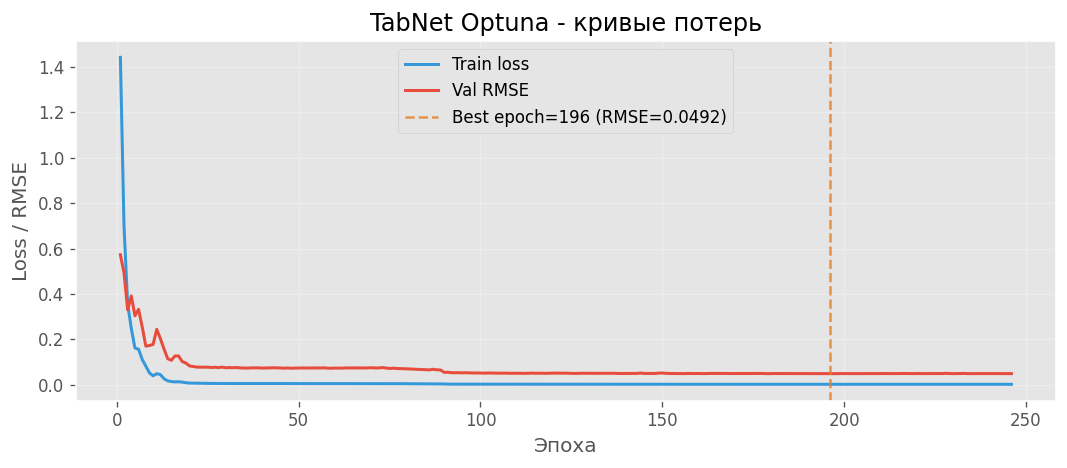

In [43]:
row_best, pred_best = report_metrics(
    'TabNet - Optuna (лучшие params)',
    model_best, X_train_np, y_train, X_test_np, y_test, fit_time_best,
)
plot_loss(model_best, 'TabNet Optuna - кривые потерь')

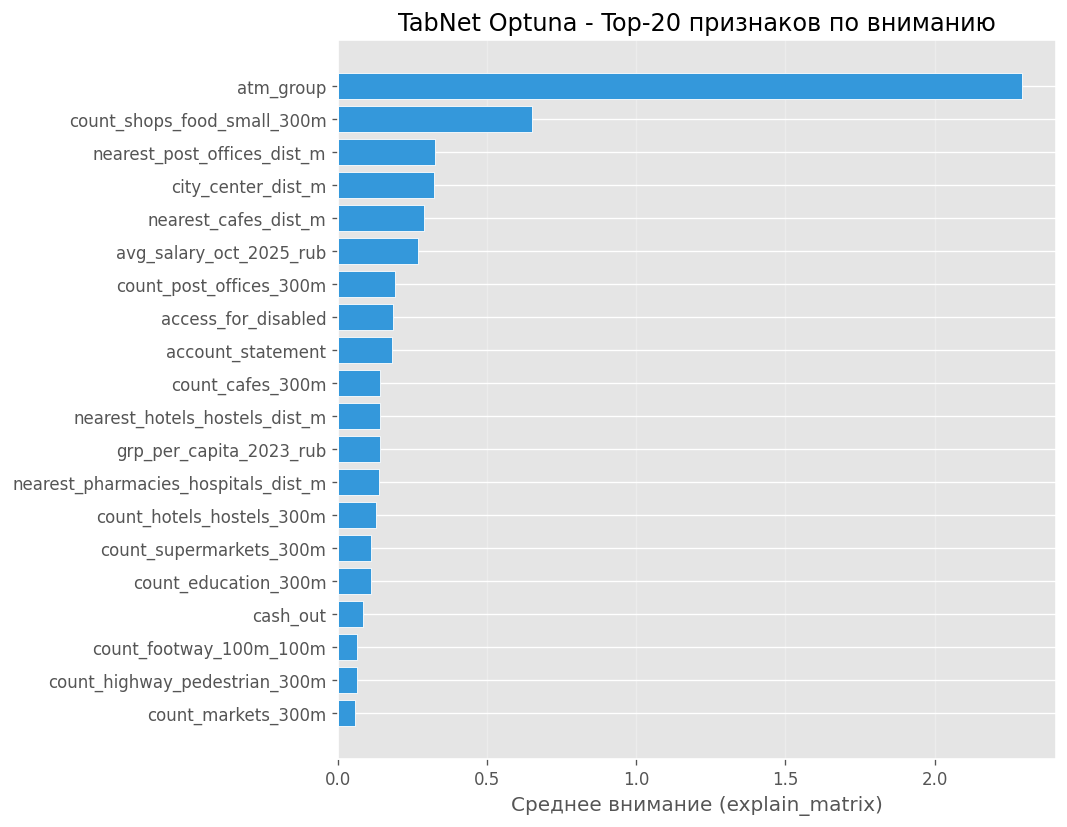

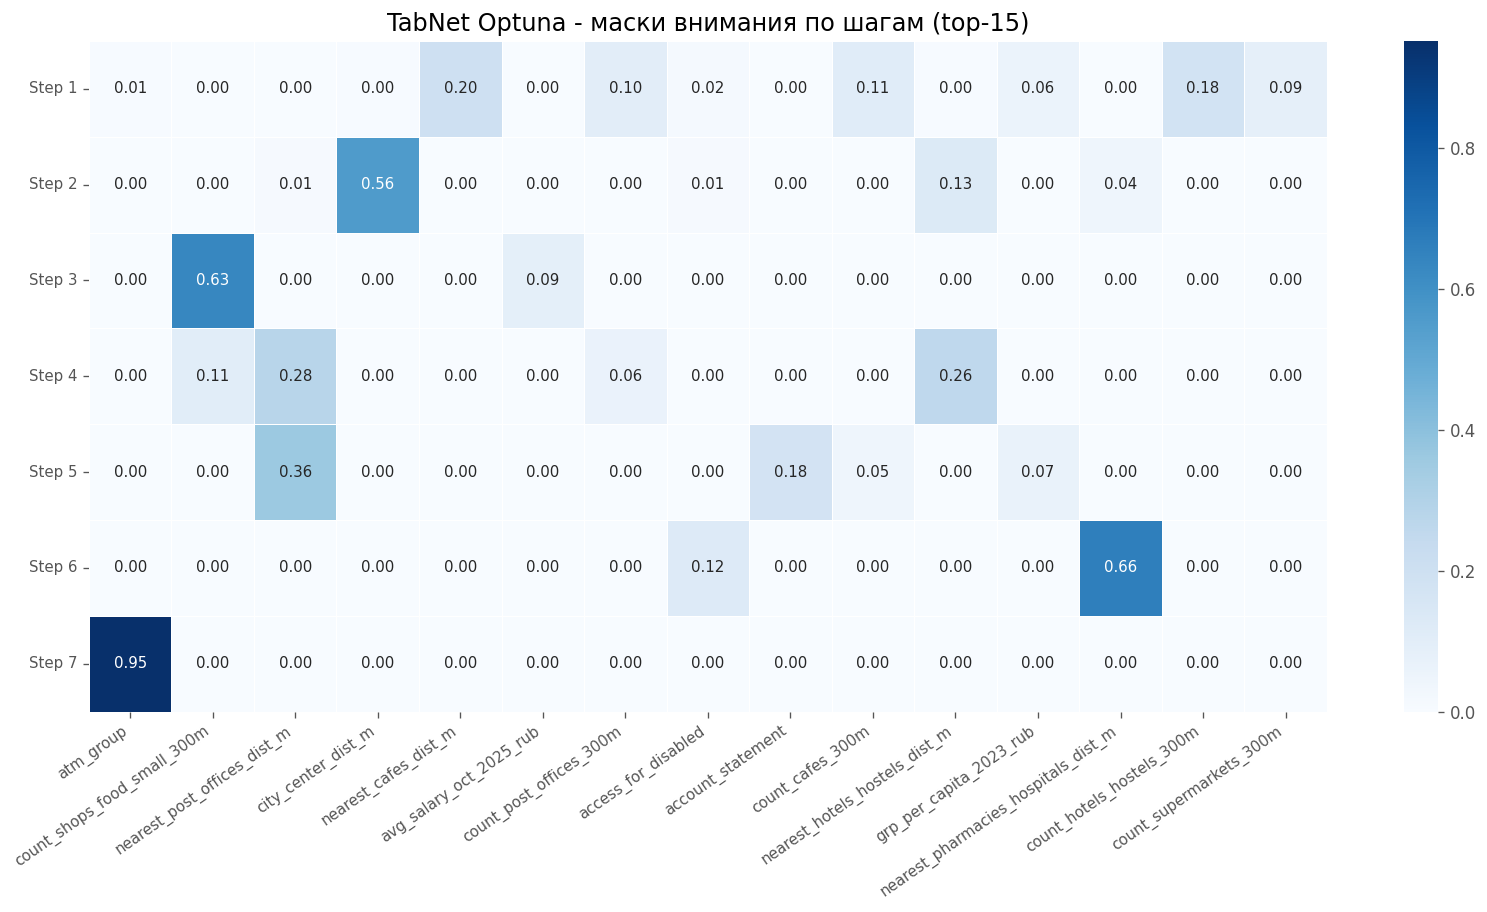

In [44]:
explain_best, masks_best = plot_attention(
    model_best, X_test_np, feat_names,
    title='TabNet Optuna',
)

## 9. Сохранение лучшей модели

In [ ]:
# Финальная модель для сохранения - переобучаем на train+val
# best_epoch берём из model_best (train→val
best_epoch_final = int(np.argmin(model_best.history['val_0_rmse'])) + 1
print(f'Переобучаем на X_trainval ({len(X_trainval_np)} объектов), {best_epoch_final} эпох...')

_model_to_save = TabNetRegressor(
    n_d=bp['n_d'], n_a=bp['n_d'],
    n_steps=bp['n_steps'],
    gamma=bp['gamma'],
    lambda_sparse=bp['lambda_sparse'],
    n_independent=2,
    n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=bp['lr']),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=30, gamma=0.9),
    momentum=bp['momentum'],
    mask_type='sparsemax',
    device_name=DEVICE,
    seed=RANDOM_STATE,
    verbose=0,
)
_model_to_save.fit(
    X_trainval_np, y_trainval_np,
    eval_set=[(X_trainval_np, y_trainval_np)],
    patience=best_epoch_final + 1,
    max_epochs=best_epoch_final,
    batch_size=1024,
    eval_metric=['rmse'],
)

save_path = str(MODELS_DIR / 'tabnet_best')
_model_to_save.save_model(save_path)
print(f'Модель сохранена: {save_path}.zip')

Переобучаем на X_trainval (5270 объектов), 196 эпох...
Stop training because you reached max_epochs = 196 with best_epoch = 188 and best_val_0_rmse = 0.06307
Successfully saved model at ..\models\tabnet_best.zip
Модель сохранена: ..\models\tabnet_best.zip


## 10. Итоговая таблица экспериментов

In [46]:
bp = study.best_params

experiments = pd.DataFrame([
    {
        'Эксперимент': 'Базовый TabNet',
        'n_d': 32, 'n_a': 32, 'n_steps': 5,
        'γ': 1.3, 'λ_sparse': 1e-3, 'lr': 2e-2,
        'RMSE': row_base['RMSE'], 'MAE': row_base['MAE'], 'R²': row_base['R²'],
        'Время обучения, с': row_base['Fit time, s'],
    },
    {
        'Эксперимент': 'TabNet + Optuna',
        'n_d': bp['n_d'], 'n_a': bp['n_d'], 'n_steps': bp['n_steps'],
        'γ': round(bp['gamma'], 3), 'λ_sparse': round(bp['lambda_sparse'], 5),
        'lr': round(bp['lr'], 5),
        'RMSE': row_best['RMSE'], 'MAE': row_best['MAE'], 'R²': row_best['R²'],
        'Время обучения, с': row_best['Fit time, s'],
    },
]).set_index('Эксперимент')

display(
    experiments.style
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²'])
    .format({
        'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
        'γ': '{:.3f}', 'λ_sparse': '{:.5f}', 'lr': '{:.5f}',
        'Время обучения, с': '{:.1f}',
    })
)

,n_d,n_a,n_steps,γ,λ_sparse,lr,RMSE,MAE,R²,"Время обучения, с"
Эксперимент,,,,,,,,,,
Базовый TabNet,32,32,5,1.300,0.00100,0.02000,0.0500,0.0403,0.6647,77.6
TabNet + Optuna,16,16,7,1.436,0.00030,0.01744,0.0491,0.0396,0.6766,59.8


## 11. Выводы

### Сравнение экспериментов TabNet

| Эксперимент | RMSE (test) | MAE (test) | R² (test) | Время обучения |
|---|---|---|---|---|
| Базовый TabNet | 0.0500 | 0.0403 | 0.6647 | ~78 с |
| **TabNet + Optuna** | **0.0491** | **0.0396** | **0.6766** | ~60 с |

Optuna дала заметное улучшение: RMSE −0.0009, R² +0.012. Разница умеренная, но стабильная - все top-5 trials сошлись в одну зону гиперпараметров.

**Лучшая конфигурация Optuna:** `n_d=16, n_steps=7, γ=1.436, λ=0.0003, lr=0.0174, momentum=0.013`.  
Характерная черта всех top-5 trials - кластеризация вокруг `n_d=16, n_steps=7`: умеренная ширина эмбеддинга при большом числе шагов внимания. Интерпретация: 7 последовательных «мягких развилок» позволяют модели разложить задачу по типам признаков (сервисы → экономика → локация), не перегружая каждый шаг широким представлением. Очень малый `λ_sparse` (0.0003) говорит о том, что на данной задаче жёсткая разреженность масок вредит - модель предпочитает использовать больше признаков одновременно.

**Почему Optuna сошлась быстрее** (~60 с vs ~78 с): `n_d=16` заметно меньше базового `n_d=32` - меньше параметров, быстрее каждая эпоха, и early stopping срабатывает раньше (epoch 245 vs 391).

### Интерпретация масок внимания

Тепловая карта показывает, что шаги внимания специализируются по типам признаков:
- **Ранние шаги** - ATM-сервисы (`cash_out`, `is_24_7`, `cash_in`): бинарные признаки, напрямую определяющие, зачем клиент идёт к банкомату
- **Средние шаги** - экономический и городской контекст (`avg_salary`, `federal_district`, `city_size_category`)
- **Поздние шаги** - локальное окружение (POI-счётчики, расстояния до инфраструктуры)

Это ключевое отличие от деревьев: TabNet показывает **последовательную логику** решений, а не просто агрегированную важность признаков.

### TabNet vs Rest

| Модель | RMSE (test) | R² (test) |
|--------|-------------|-----------|
| LinearRegression (лучшая) | 0.0596 | 0.5235 |
| Decision Tree (Optuna) | 0.0484 | 0.6858 |
| TabNet базовый | 0.0500 | 0.6647 |
| TabNet + Optuna | 0.0491 | 0.6766 |
| CatBoost (Optuna) | 0.0453 | 0.7249 |
| XGBoost (Baseline) | 0.0451 | 0.7276 |
| LightGBM (Optuna) | 0.0448 | 0.7307 |
| **Random Forest (Optuna)** | **0.0444** | **0.7359** |

TabNet уступает лучшей модели (Random Forest Optuna) ~11% по RMSE. Это типичный результат для DL-моделей на небольших табличных датасетах:
- Градиентный бустинг и случайный лес созданы специально для табличных задач: явная обработка категорий, устойчивость к выбросам, не требуют нормализации
- TabNet требует больше данных для обучения эмбеддингов; при 6 200 строках его потенциал раскрывается не полностью
- Главное преимущество TabNet - **интерпретируемость «из коробки»** (маски внимания по шагам) без SHAP/LIME